In [157]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

# Data handling
import pandas as pd
import numpy as np
import sqlite3
import os

# Database
from sqlalchemy import create_engine

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

# Explainability
import shap

# Model persistence
import joblib
import mlflow
import mlflow.sklearn
import dagshub

dagshub.init(repo_owner='mrDanbatta', repo_name='shift-optimisation-system')

sns.set(style="whitegrid")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

c:\Users\mrdan\AppData\Local\Programs\Python\Python311\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=7d8b2ca1-b9bc-4a0d-a0fc-0a16268cfdaa&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=05b70969076b395f77e16e862f745f02db210d49e78d62f62f5f11e8b5e71932




Accessing as mrDanbatta

Repository shift-optimisation-system doesn't exist, creating it under current user.

Initialized MLflow to track repo "mrDanbatta/shift-optimisation-system"

Repository mrDanbatta/shift-optimisation-system initialized!

Connecting to the database

In [91]:
engine = create_engine("sqlite:///ShiftData.db")

with engine.connect() as connection:
    
    print("Database Connected")
    
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        connection
    )

tables

Database Connected


,name
0,ShiftPerformance


There is only one table in the database

In [92]:
# create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

file_path = "data/ShiftPerformance.csv"

# check if file already exists
if not os.path.exists(file_path):
    df = pd.read_sql("SELECT * FROM ShiftPerformance", engine)
    df.to_csv("data/ShiftPerformance.csv", index=False)
    print("CSV exported successfully")
    
else:
    print("CSV already exists. Skipping export")

CSV already exists. Skipping export


In [93]:
# create a working dataset
df = pd.read_sql("SELECT * FROM ShiftPerformance", engine)
df_work = df.copy()

In [94]:
df_work.shape

(296334, 31)

In [95]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [97]:
df_work.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [98]:
# clean time columns
# normalize time strings like "06:00:00.0000000" -> "06:00:00"
for col in ["start_time", "end_time"]:
    df_work[col] =(
        df_work[col]
        .astype(str)
        .str.replace(r"\.\d+$", "", regex = True)
    )


df_work["start_time"] = pd.to_datetime(
    df_work["start_time"],
    format="%H:%M:%S",
    errors="coerce"
)

df_work["end_time"] = pd.to_datetime(
    df_work["end_time"],
    format="%H:%M:%S",
    errors="coerce"
)

df_work["date"] = pd.to_datetime(df_work["date"], errors="coerce")

df_work["timestamp"] = pd.to_datetime(df_work["timestamp"], errors="coerce")

In [99]:
# now check the df_work.info()

df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [100]:
# Timestamp range check
# We do the timestamp range check to understand the time coverage of the dataset. 
# It tells us when the data starts and when it ends.
# From what date to what date does this dataset cover?

print("Earliest record:", df_work["timestamp"].min())
print("Latest record:", df_work["timestamp"].max())

Earliest record: 2024-01-01 08:00:00
Latest record: 2024-03-31 16:00:00


In [101]:
# check missing production days

full_dates = pd.date_range(
    df_work["date"].min(),
    df_work["date"].max()
)

missing_dates = full_dates.difference(
    df_work["date"].unique()
)

print("Missing production days:", len(missing_dates))

Missing production days: 0


In [102]:
# check shift distribution

df_work["shift_name"].value_counts()

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64

In [103]:
# check for duplicate records

df_work.duplicated().sum()

np.int64(0)

In [104]:
# check for missing values
df_work.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [105]:
# handle missing values

# maintenance events
df_work["maintenance_downtime"] = df_work["maintenance_downtime"].fillna(0)
df_work['maintenance_id'] = df_work['maintenance_id'].fillna('No_Maintenance')
df_work['issue_type'] = df_work['issue_type'].fillna('No_Issue')
df_work['resolved_by'] = df_work['resolved_by'].fillna('No_Resolver')

# environmental sensors
df_work["temperature"] = df_work["temperature"].fillna(
    df_work["temperature"].median()
)

df_work["humidity"] = df_work["humidity"].fillna(
    df_work["humidity"].median()
)

# timestamp
df_work["timestamp"] = df_work["timestamp"].fillna(method="ffill")

C:\Users\mrdan\AppData\Local\Temp\ipykernel_7792\1744985362.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_work["timestamp"] = df_work["timestamp"].fillna(method="ffill")


In [106]:
df_work.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
maintenance_id            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

In [107]:
# Create binary feature indicating whether maintenance occurred
# 1 = maintenance happened
# 0 = no maintenance

df_work["maintenance_event"] = df_work["maintenance_id"].notna().astype(int)

In [108]:
df_work["maintenance_event"].value_counts()

maintenance_event
1    296334
Name: count, dtype: int64

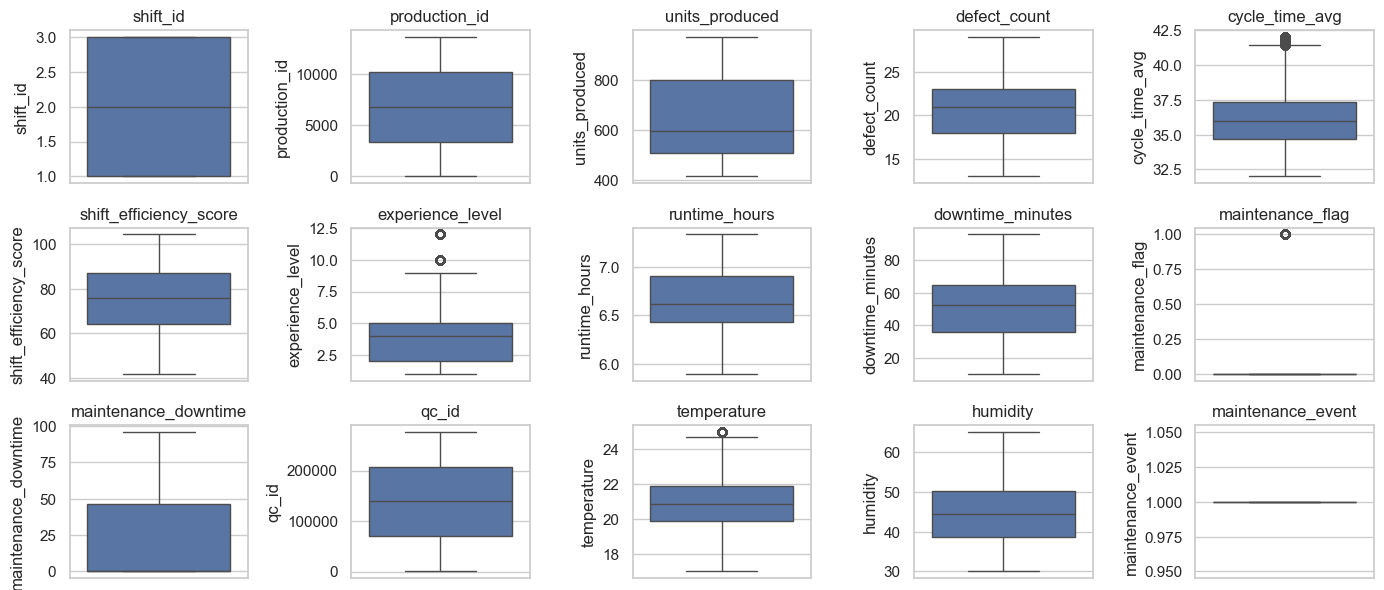

In [109]:
numeric_cols = df_work.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,10))

for i, col in enumerate(numeric_cols, 1):
    
    plt.subplot(5,5,i)
    sns.boxplot(y=df_work[col])
    plt.title(col)

plt.tight_layout()

plt.show()

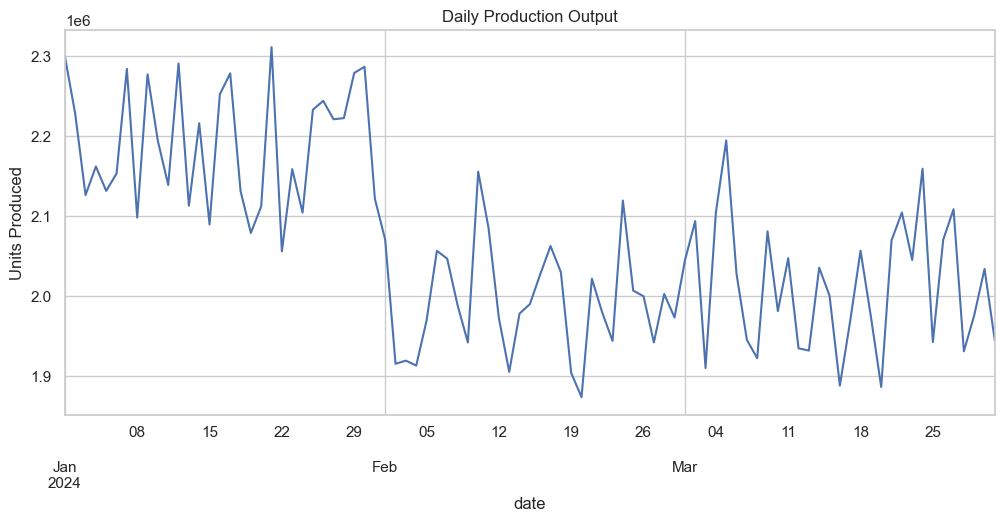

In [110]:
# daily production trend

daily_production = df_work.groupby("date")["units_produced"].sum()

plt.figure(figsize=(12,5))

daily_production.plot()

plt.title("Daily Production Output")

plt.ylabel("Units Produced")

plt.show()

In [111]:
# categorical distribution

# showing the different type of the categorical columns
print("Unique Operators:", df['operator_name'].nunique(), df['operator_id'].unique())
print("=" * 100)
print("Experience Levels:", df['experience_level'].nunique(), np.sort(df['experience_level'].unique()))
print("=" * 100)
print("Skill Category:", df['skill_category'].nunique(), np.sort(df['skill_category'].unique()))
print("=" * 100)
print("Issue Types:", df['issue_type'].nunique(), df['issue_type'].unique())
print("=" * 100)
print("Resolved by Shift:", df['resolved_by'].nunique(), df['resolved_by'].unique())
print("=" * 100)
print("Maintenance Flags", df['maintenance_flag'].nunique(), np.sort(df['maintenance_flag'].unique()))
print("=" * 100)
print("Defect Types:", df['defect_type'].nunique(), df['defect_type'].unique())
print("=" * 100)
print("Severity Levels:", df['severity'].nunique(), df['severity'].unique())
print("=" * 100)
print("Inspection result:", df['inspection_result'].nunique(), df['inspection_result'].unique())

Unique Operators: 110 ['OP_019' 'OP_033' 'OP_069' 'OP_090' 'OP_051' 'OP_119' 'OP_068' 'OP_014'
 'OP_078' 'OP_048' 'OP_041' 'OP_026' 'OP_102' 'OP_037' 'OP_081' 'OP_012'
 'OP_049' 'OP_044' 'OP_052' 'OP_032' 'OP_053' 'OP_115' 'OP_013' 'OP_084'
 'OP_076' 'OP_001' 'OP_063' 'OP_105' 'OP_004' 'OP_008' 'OP_118' 'OP_074'
 'OP_080' 'OP_096' 'OP_002' 'OP_021' 'OP_045' 'OP_015' 'OP_009' 'OP_073'
 'OP_005' 'OP_067' 'OP_047' 'OP_010' 'OP_098' 'OP_066' 'OP_117' 'OP_016'
 'OP_020' 'OP_097' 'OP_017' 'OP_003' 'OP_006' 'OP_043' 'OP_025' 'OP_092'
 'OP_034' 'OP_089' 'OP_042' 'OP_039' 'OP_107' 'OP_040' 'OP_027' 'OP_087'
 'OP_101' 'OP_038' 'OP_070' 'OP_099' 'OP_057' 'OP_030' 'OP_088' 'OP_071'
 'OP_059' 'OP_110' 'OP_079' 'OP_100' 'OP_023' 'OP_029' 'OP_108' 'OP_109'
 'OP_022' 'OP_113' 'OP_094' 'OP_104' 'OP_116' 'OP_050' 'OP_055' 'OP_060'
 'OP_018' 'OP_065' 'OP_114' 'OP_007' 'OP_120' 'OP_036' 'OP_112' 'OP_106'
 'OP_061' 'OP_028' 'OP_031' 'OP_086' 'OP_024' 'OP_046' 'OP_091' 'OP_054'
 'OP_075' 'OP_103' 'OP_082' '

In [112]:
# Aggregate machine logs into production runs

production_df = (
    df_work.groupby("production_id")
    .agg(
        machine_id=("machine_id","first"),
        shift_id=("shift_id","first"),
        shift_name=("shift_name","first"),
        units_produced=("units_produced","max"),
        defect_count=("defect_count","sum"),
        runtime_hours=("runtime_hours","mean")
    )
    .reset_index()
)

In [113]:
#  Calculate production rate
production_df["output_per_hour"] = (
    production_df["units_produced"] /
    production_df["runtime_hours"]
)

production_df.head()

,production_id,machine_id,shift_id,shift_name,units_produced,defect_count,runtime_hours,output_per_hour
0,1,MC_001,1,Morning,929,400,7.24,128.314917
1,2,MC_002,1,Morning,873,256,7.13,122.440393
2,3,MC_003,1,Morning,904,400,7.16,126.256983
3,4,MC_004,1,Morning,930,256,7.29,127.572016
4,5,MC_005,1,Morning,867,484,7.24,119.751381


In [114]:
# Aggregate production data to shift level

shift_df = (
    df_work.groupby(["shift_id","shift_name","date"])
    .agg(
        units_produced=("units_produced","max"),
        defect_count=("defect_count","mean"),
        shift_efficiency_score=("shift_efficiency_score","mean"),
        cycle_time_avg=("cycle_time_avg","mean"),
        experience_level=("experience_level","mean"),
        runtime_hours=("runtime_hours","mean"),
        downtime_minutes=("downtime_minutes","sum"),
        maintenance_downtime=("maintenance_downtime","sum"),
        maintenance_events=("maintenance_event","sum"),
        temperature=("temperature","mean"),
        humidity=("humidity","mean"),
        num_operators=("operator_id","nunique"),
        num_machines=("machine_id","nunique")
    )
    .reset_index()
)

In [115]:
shift_df.head()

,shift_id,shift_name,date,units_produced,defect_count,shift_efficiency_score,cycle_time_avg,experience_level,runtime_hours,downtime_minutes,maintenance_downtime,maintenance_events,temperature,humidity,num_operators,num_machines
0,1,Morning,2024-01-01,965,19.590009,93.631067,36.100707,6.493874,7.221508,17713.90,15966.57,1061,22.3,49.9,29,50
1,1,Morning,2024-01-02,958,19.372454,94.468776,36.163783,6.762367,7.238080,16178.39,17306.39,1031,17.7,45.1,26,50
2,1,Morning,2024-01-03,965,18.977320,95.102957,35.737412,6.520619,7.264299,13689.79,11709.48,970,23.6,30.0,27,50
3,1,Morning,2024-01-04,958,19.078629,94.714046,36.105655,6.825605,7.264365,13969.95,15596.52,992,18.4,48.5,33,50
4,1,Morning,2024-01-05,962,19.114402,94.744196,36.274351,7.160368,7.244545,14934.32,10834.88,979,19.8,48.2,28,50


In [116]:
df.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


Checking for outliers

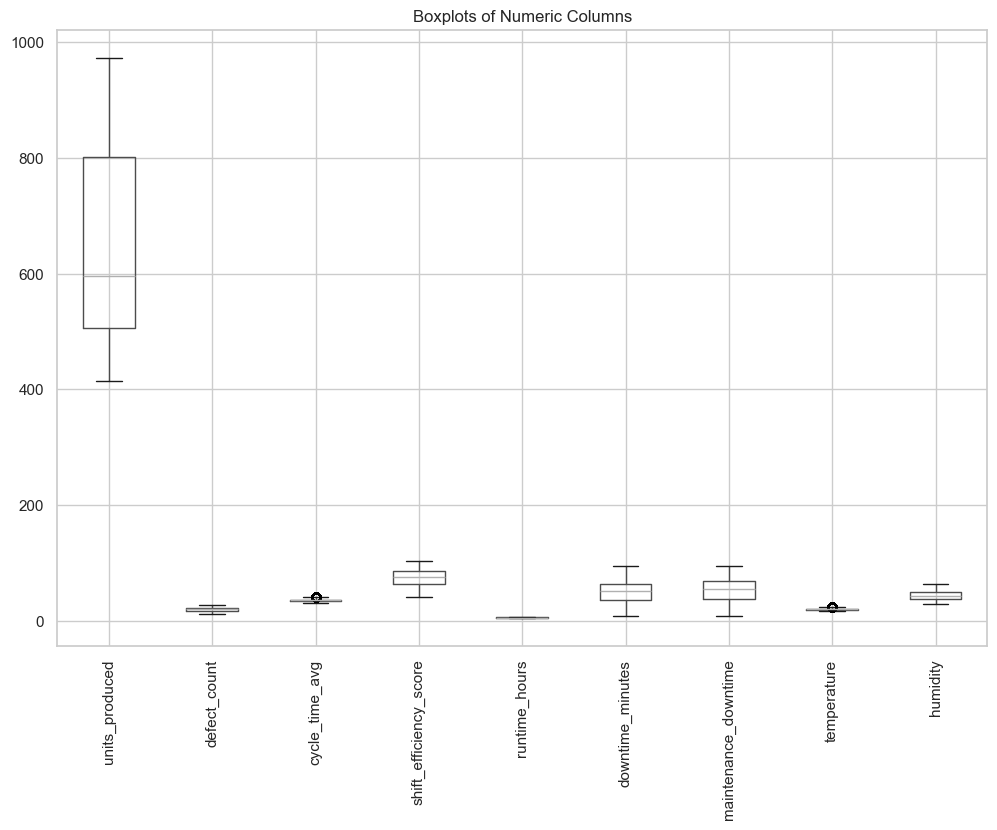

In [117]:
numeric_cols = ['units_produced', 'defect_count', 'cycle_time_avg', 
                'shift_efficiency_score', 'runtime_hours', 'downtime_minutes', 
                'maintenance_downtime', 'temperature', 'humidity']

plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot(rot=90)
plt.title('Boxplots of Numeric Columns')
plt.show()

The boxplot shows the cycle time avg and temperature both have outliers.

Winsorization can be used to handle the outliers

Getting outlier values

In [118]:
def get_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    return mask

iqr_outliers = pd.DataFrame()

for col in numeric_cols:
    iqr_outliers[col] = get_iqr_outliers(df, col)

print(iqr_outliers.sum())

units_produced               0
defect_count                 0
cycle_time_avg            1264
shift_efficiency_score       0
runtime_hours                0
downtime_minutes             0
maintenance_downtime         0
temperature               1216
humidity                     0
dtype: int64


Fixing outliers

In [119]:
def winsorize(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

In [120]:
outlier_cols = iqr_outliers.columns[iqr_outliers.sum() > 0]
print("Columns with outliers:", outlier_cols)
for col in outlier_cols:
    df = winsorize(df, col)
print("Outliers have been winsorized in columns:", outlier_cols)

Columns with outliers: Index(['cycle_time_avg', 'temperature'], dtype='object')
Outliers have been winsorized in columns: Index(['cycle_time_avg', 'temperature'], dtype='object')


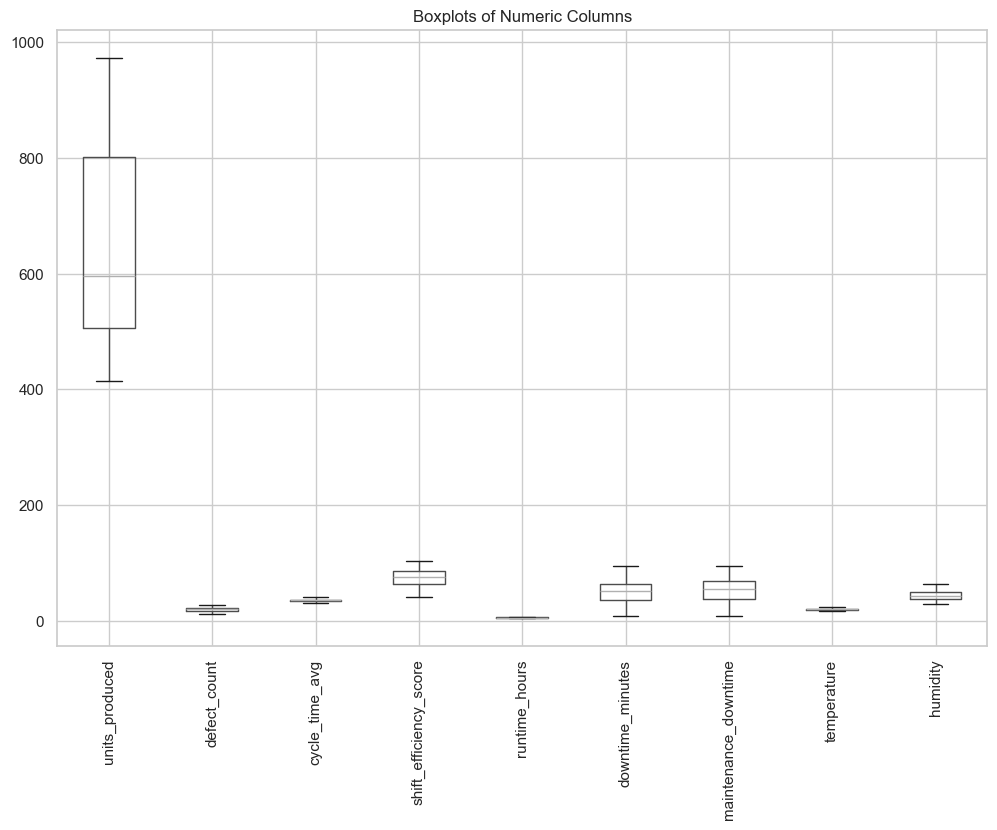

In [121]:
numeric_cols = ['units_produced', 'defect_count', 'cycle_time_avg', 
                'shift_efficiency_score', 'runtime_hours', 'downtime_minutes', 
                'maintenance_downtime', 'temperature', 'humidity']

plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot(rot=90)
plt.title('Boxplots of Numeric Columns')
plt.show()

### Feature Engineering

In [122]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [123]:
# Feature engineering: create new features based on existing ones
#Output per hour
shift_summary = df_work.groupby('production_id').agg({
    'units_produced': 'max',
    'defect_count': 'first',
    'start_time': 'first',
    'end_time': 'first'
})

shift_duration = shift_summary['end_time'] - shift_summary['start_time']
shift_duration = shift_duration.where(
    shift_duration >= pd.Timedelta(0),
    shift_duration + pd.Timedelta(days=1)
)

shift_summary['output_per_hour'] = (
    shift_summary['units_produced'] / (shift_duration.dt.total_seconds() / 3600)
)

df_work['output_per_hour'] = df_work['production_id'].map(shift_summary['output_per_hour'])

# efficiency index: ratio of actual output to maximum output per hour across all shifts
df_work['efficiency_index'] = df_work['output_per_hour'] / df_work['output_per_hour'].max()

# defect rate: ratio of defective units to total units produced
df_work['defect_rate'] = df_work['defect_count'] / df_work['units_produced'].replace(0, np.nan)

# OEE (Overall Equipment Efficiency): Combine machine availability, performance, and quality into one score.
df_work['oee'] = (df_work['runtime_hours'] / (df_work['runtime_hours'] + df_work['downtime_minutes'] / 60)) * \
            (df_work['output_per_hour'] / df_work['output_per_hour'].max()) * \
            (1 - df_work['defect_rate'])

In [124]:
df_work[['output_per_hour','efficiency_index', 'defect_rate', 'oee']]

,output_per_hour,efficiency_index,defect_rate,oee
0,116.125,0.955761,0.021529,0.903187
1,116.125,0.955761,0.021529,0.903187
2,116.125,0.955761,0.021529,0.903187
3,116.125,0.955761,0.021529,0.903187
4,116.125,0.955761,0.021529,0.903187
...,...,...,...,...
296329,63.750,0.524691,0.039216,0.418089
296330,63.750,0.524691,0.039216,0.418089
296331,63.750,0.524691,0.039216,0.418089
296332,63.750,0.524691,0.039216,0.418089


### Exploratory Data Analysis

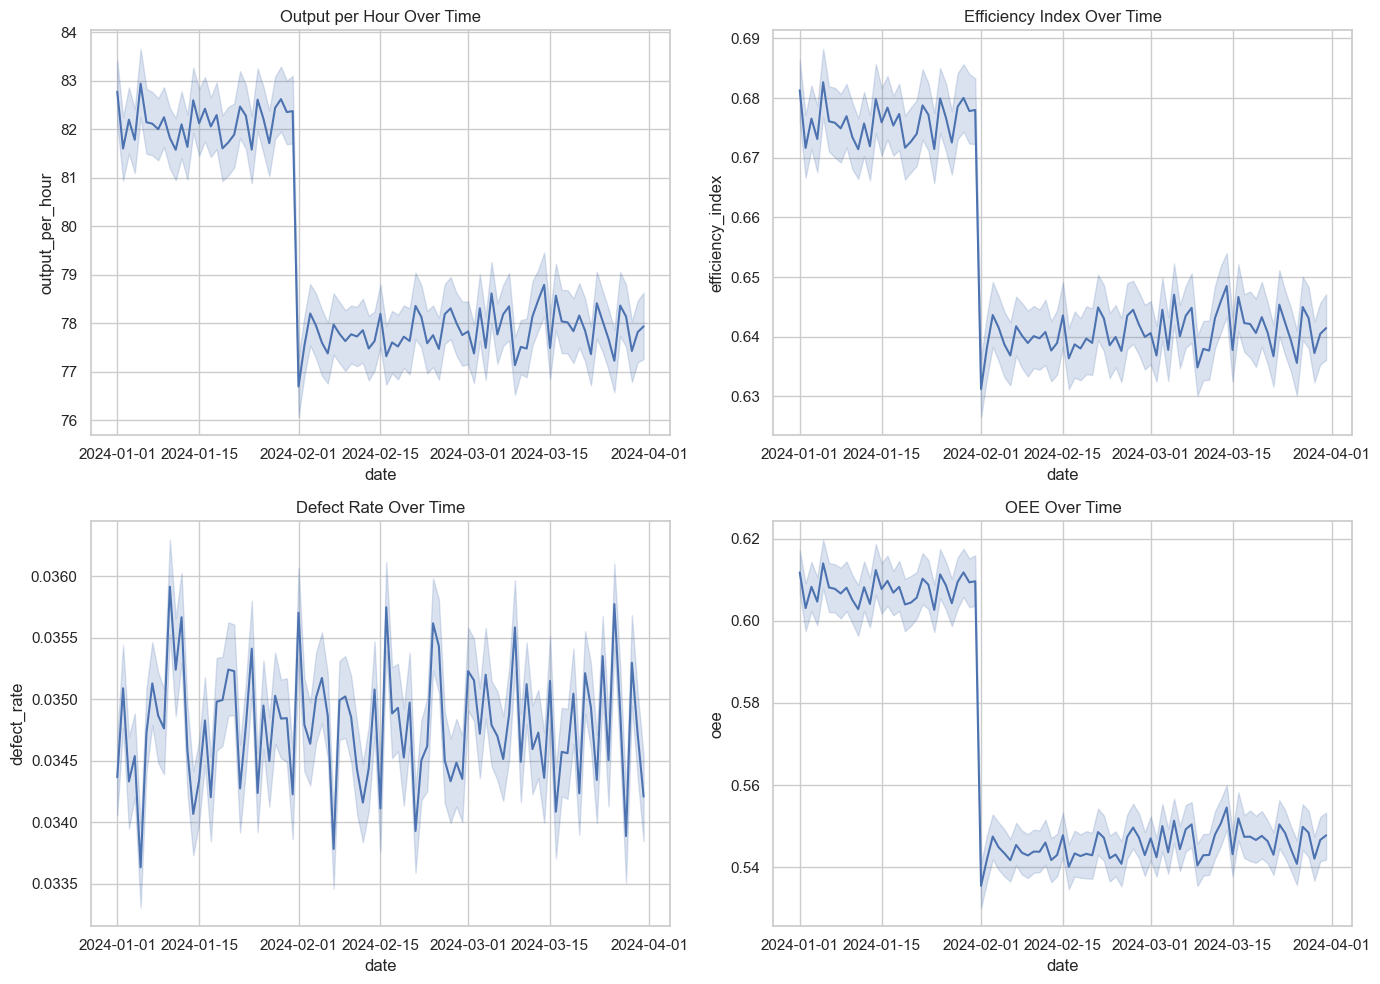

In [125]:
# visualize shift trends with multiple metrics
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
sns.lineplot(data=df_work, x='date', y='output_per_hour')
plt.title('Output per Hour Over Time')
plt.subplot(2, 2, 2)
sns.lineplot(data=df_work, x='date', y='efficiency_index')
plt.title('Efficiency Index Over Time')
plt.subplot(2, 2, 3)
sns.lineplot(data=df_work, x='date', y='defect_rate')
plt.title('Defect Rate Over Time')
plt.subplot(2, 2, 4)
sns.lineplot(data=df_work, x='date', y='oee')
plt.title('OEE Over Time')
plt.tight_layout()

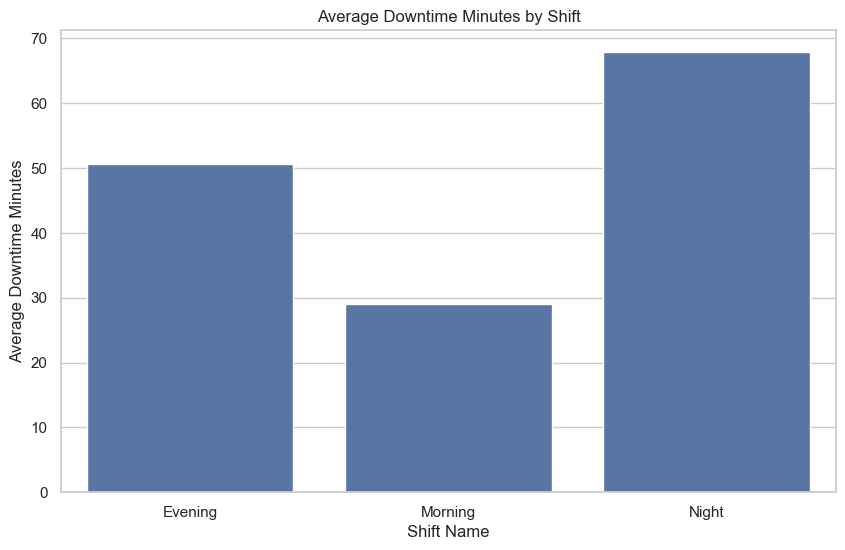

In [126]:
# distrubution of downtime across shifts
shifts_downtime = df_work.groupby('shift_name').agg({'downtime_minutes': 'mean'}).reset_index()
shifts_downtime
plt.figure(figsize=(10, 6))
plt.subplot(1, 1, 1)
sns.barplot(data=shifts_downtime, x='shift_name', y='downtime_minutes')
plt.title('Average Downtime Minutes by Shift')
plt.xlabel('Shift Name')
plt.ylabel('Average Downtime Minutes')
plt.show()

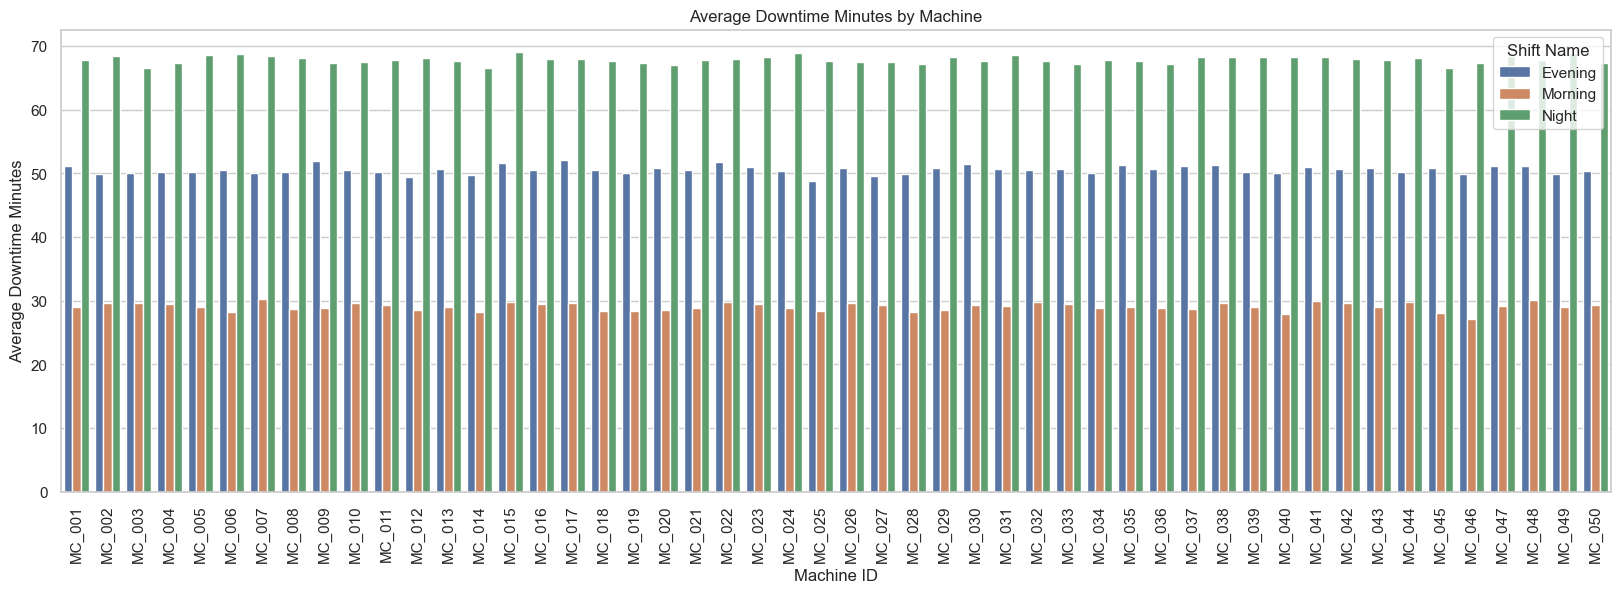

In [127]:
machine_availability = df_work.groupby(['machine_id', 'shift_name']).agg({'downtime_minutes': 'mean'}).reset_index()
machine_availability
plt.figure(figsize=(20, 6))
sns.barplot(data=machine_availability, x='machine_id', y='downtime_minutes', hue='shift_name')
plt.xticks(rotation=90)
plt.title('Average Downtime Minutes by Machine')
plt.xlabel('Machine ID')
plt.ylabel('Average Downtime Minutes')
plt.legend(title='Shift Name')
plt.show()


# plt.figure(figsize=(10, 6))


Analysing skewness of the target variable

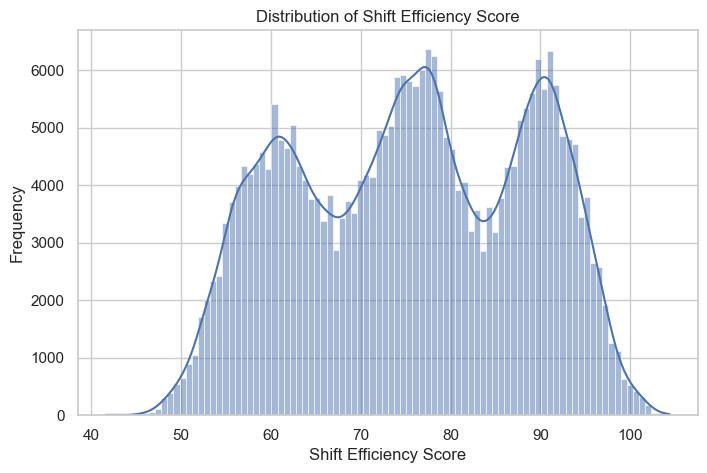

In [128]:
# checking the skewness of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df_work['shift_efficiency_score'], kde=True)
plt.title('Distribution of Shift Efficiency Score')
plt.xlabel('Shift Efficiency Score')
plt.ylabel('Frequency')
plt.show()

Feature Selection

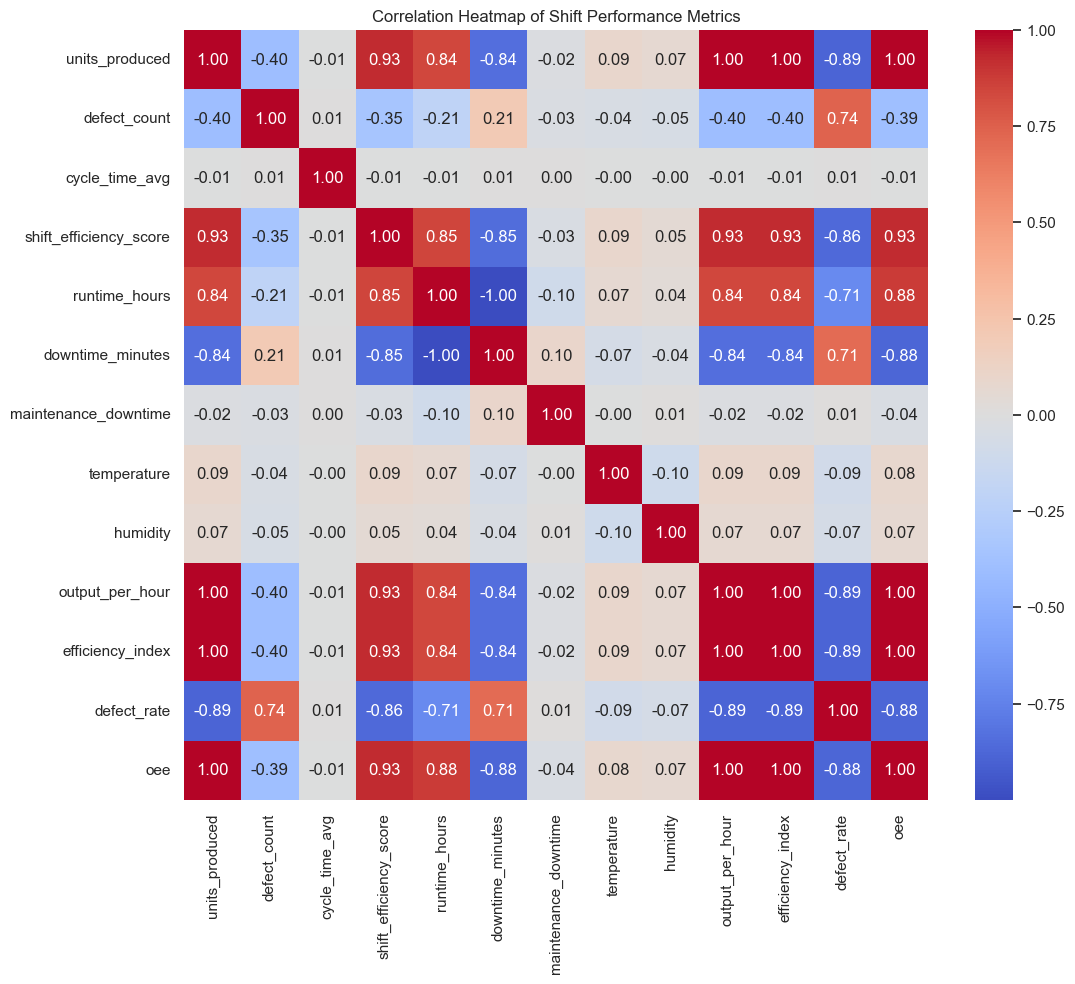

In [129]:
# feature selction using correlation heatmap
numeric_cols = ['units_produced', 'defect_count', 'cycle_time_avg', 
                'shift_efficiency_score', 'runtime_hours', 'downtime_minutes', 
                'maintenance_downtime', 'temperature', 'humidity',
                'output_per_hour', 'efficiency_index', 'defect_rate', 'oee']
plt.figure(figsize=(12, 10))
sns.heatmap(df_work[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Shift Performance Metrics')
plt.show()

In [130]:
df_work.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity', 'timestamp',
       'maintenance_event', 'output_per_hour', 'efficiency_index',
       'defect_rate', 'oee'],
      dtype='object')

In [133]:
features = ['shift_name', 'supervisor_id', 'defect_count', 
            'cycle_time_avg', 'operator_id', 'experience_level', 
            'skill_category', 'maintenance_downtime', 'maintenance_flag', 
            'machine_status', 'issue_type', 'inspection_result', 
            'temperature', 'humidity']

target = ['shift_efficiency_score']

In [134]:
final_df = df_work[features + target]

In [135]:
final_df.shape

(296334, 15)

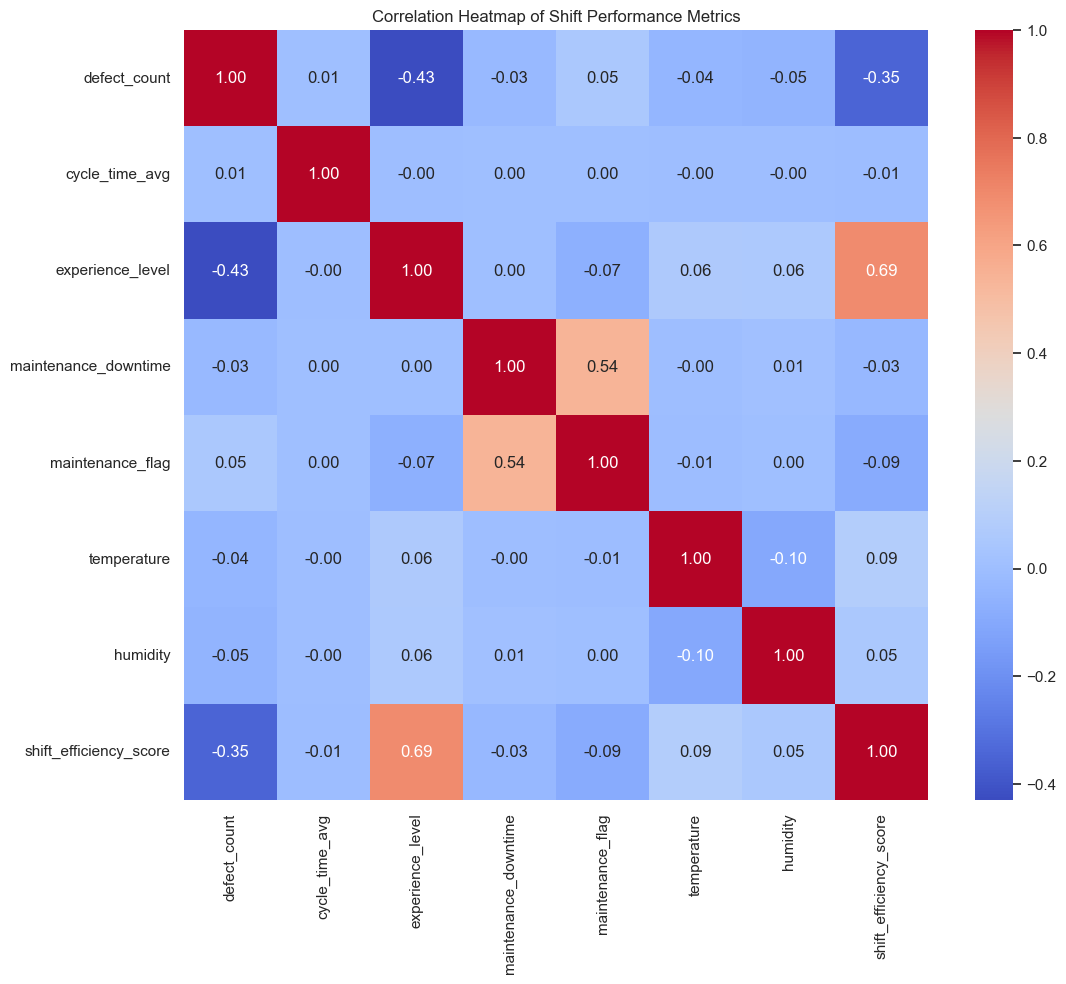

In [158]:
numeric_cols = final_df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12, 10))
sns.heatmap(final_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Shift Performance Metrics')
plt.show()

In [138]:
# Identify numeric and categorical features
numeric_features = final_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove('shift_efficiency_score')
categorical_features = final_df.select_dtypes(include=['object']).columns.tolist()

# define numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# define categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
]).set_output(transform="pandas")

# apply preprocessing to the final dataframe

final_df_processed = preprocessor.fit_transform(final_df)

print("Original shape of final_df:", final_df.shape)
print("Processed shape of final_df:", final_df_processed.shape)

Original shape of final_df: (296334, 15)
Processed shape of final_df: (296334, 138)


In [139]:
final_df_processed.head()

,num__defect_count,num__cycle_time_avg,num__experience_level,num__maintenance_downtime,num__maintenance_flag,num__temperature,num__humidity,cat__shift_name_Evening,cat__shift_name_Morning,cat__shift_name_Night,...,cat__machine_status_Operational,cat__issue_type_Calibration,cat__issue_type_Electrical,cat__issue_type_Mechanical,cat__issue_type_No_Issue,cat__issue_type_Preventive,cat__issue_type_Software,cat__inspection_result_Accepted,cat__inspection_result_Rejected,cat__inspection_result_Rework
0,-0.228203,-0.187096,1.206288,-0.72592,-0.471234,0.919214,0.685667,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.228203,-0.187096,1.206288,-0.72592,-0.471234,0.919214,0.685667,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.228203,-0.187096,1.206288,-0.72592,-0.471234,0.919214,0.685667,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.228203,-0.187096,1.206288,-0.72592,-0.471234,0.919214,0.685667,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.228203,-0.187096,1.206288,-0.72592,-0.471234,0.919214,0.685667,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [142]:
# split data into features and target
X_train, X_test, y_train, y_test = train_test_split(final_df_processed, final_df['shift_efficiency_score'], test_size=0.2, random_state=42)

### Model Development
1. Linear Regression
2. Random Forest

In [144]:
# initialize linear regression model
linear_model = LinearRegression()

# initialize random forest regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


In [145]:
# fit models
linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [147]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
    mae = round(mean_absolute_error(y_test, y_pred), 2)
    r2 = round(r2_score(y_test, y_pred), 2)
    return rmse, mae, r2

In [148]:
linear_regression_results = evaluate_model(linear_model, X_test, y_test)
rf_results = evaluate_model(rf_model, X_test, y_test)

print("Linear Regression Results")
print("RSME", linear_regression_results[0])
print("MAE", linear_regression_results[1])
print("R2", linear_regression_results[2]) 
print("\n" + "=" * 50)

print("Random Forest Results")
print("RSME", rf_results[0])
print("MAE", rf_results[1])
print("R2", rf_results[2])
print("\n" + "=" * 50)


Linear Regression Results
RSME 3.95
MAE 3.16
R2 0.91

Random Forest Results
RSME 0.0
MAE 0.0
R2 1.0



In [150]:
# Define hyperparameter grid for Random Forest
from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  # number of parameter settings sampled
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,  # use all processors
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV R² score:", round(random_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Best CV R² score: 0.9965


In [151]:
# Get the best model from RandomizedSearchCV
best_rf_model = random_search.best_estimator_

# Evaluate the tuned model
tuned_rmse, tuned_mae, tuned_r2 = evaluate_model(best_rf_model, X_test, y_test)

print("=" * 50)
print("Tuned Random Forest Regressor Results")
print("RMSE:", tuned_rmse)
print("MAE:", tuned_mae)
print("R²:", tuned_r2)
print("=" * 50)

# Compare with original model
print("\nComparison:")
print(f"Original RF - RMSE: {rf_results[0]}, MAE: {rf_results[1]}, R²: {rf_results[2]}")
print(f"Tuned RF - RMSE: {tuned_rmse}, MAE: {tuned_mae}, R²: {tuned_r2}")

Tuned Random Forest Regressor Results
RMSE: 0.58
MAE: 0.22
R²: 1.0

Comparison:
Original RF - RMSE: 0.0, MAE: 0.0, R²: 1.0
Tuned RF - RMSE: 0.58, MAE: 0.22, R²: 1.0


In [152]:
# Define hyperparameter grid for Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Initialize GridSearchCV with Ridge
grid_search_ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1
)

# Fit GridSearchCV
grid_search_ridge.fit(X_train, y_train)

print("Best parameters:", grid_search_ridge.best_params_)
print("Best CV R² score:", round(grid_search_ridge.best_score_, 4))

# Get the best model
best_ridge_model = grid_search_ridge.best_estimator_

# Evaluate
tuned_rmse, tuned_mae, tuned_r2 = evaluate_model(best_ridge_model, X_test, y_test)
print("=" * 50)
print("Best Ridge Model Results")
print("RMSE:", tuned_rmse)
print("MAE:", tuned_mae)
print("R²:", tuned_r2)
print("=" * 50)

# compare with original Linear Regression model
print("\nComparison:")
print(f"Original Linear Regression - RMSE: {linear_regression_results[0]}, MAE: {linear_regression_results[1]}, R²: {linear_regression_results[2]}")
print(f"Best Ridge Model - RMSE: {tuned_rmse}, MAE: {tuned_mae}, R²: {tuned_r2}")

Best parameters: {'alpha': 100}
Best CV R² score: 0.9058
Best Ridge Model Results
RMSE: 3.95
MAE: 3.16
R²: 0.91

Comparison:
Original Linear Regression - RMSE: 3.95, MAE: 3.16, R²: 0.91
Best Ridge Model - RMSE: 3.95, MAE: 3.16, R²: 0.91
